# Stage 5 — Land-Use Pressure (Mole Creek prototype)

**Data access:** a `pystac_client` search against DEA's public STAC catalogue, with `odc.stac.load` bringing the data in already reprojected to EPSG:7855. **Resampling and reclassification** use `rioxarray` and numpy, with no PyQGIS: reproject and resample via `.rio.reproject_match()` (nearest-neighbour, since land cover is categorical), and reclassify via a numpy lookup. The fetch and reclassify live in `src/landuse.py` as `fetch_landuse_pressure()`, shared with Stages 7 and 9.

Both DEA epochs (2010, 2020) are fetched so the change between them can be compared (Stage 9).


In [1]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import numpy as np
import rasterio
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure
from mapping import add_attribution, add_basemap, data_bounds, finish_map, plot_scores, scores_legend

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

mole_creek = gpd.read_file(str(outpath / "mole_creek_bounding_box_EPSG7855.gpkg"))
mole_creek_wgs84 = mole_creek.to_crs("EPSG:4326")  # DEA STAC search requires WGS84 lon/lat
bbox = mole_creek_wgs84.total_bounds.tolist()


## 5.1 Fetch + reclassify to a pressure scale

The fetch and reclassify live in `src/landuse.py` (`fetch_landuse_pressure`), shared with Stages 7 and 9. No authentication is needed: the STAC catalogue is public, with anonymous S3 access.

Level-3 classes present at Mole Creek: 111 (cultivated terrestrial vegetation), 112 (natural terrestrial vegetation), 215 (artificial surface), 216 (natural bare surface), 220 (water), 255 (no data). The scale is kept simple (per the revised workflow's land-use table), on the same 0-3 ordinal scale as the other layers:

| Level-3 class | Pressure score |
|---|---|
| 111 Cultivated terrestrial vegetation | 3 (High -- agriculture) |
| 112 Natural terrestrial vegetation | 1 (Low) |
| 124 Natural aquatic vegetation | 1 (Low) |
| 215 Artificial surface | 3 (High -- urban/development) |
| 216 Natural bare surface | 1 (Low -- natural, not human pressure) |
| 220 Water | 0 (None) |
| 255 No data | excluded |


In [2]:
dem_template_path = outpath / "dem_mc_EPSG7855.tif"

pressure_by_year = {}
for year in [2010, 2020]:
    pressure_aligned = fetch_landuse_pressure(bbox, year, dem_template_path, cache_dir=data / "Input_data" / "DEA_Land_Cover_Cache")
    pressure_by_year[year] = pressure_aligned

    with rasterio.open(dem_template_path) as ref:
        profile = ref.profile.copy()
    profile.update(dtype="uint8", nodata=255, count=1)
    out_path = outpath / f"landuse_pressure_mc_{year}_EPSG7855.tif"
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(pressure_aligned, 1)

with rasterio.open(dem_template_path) as dem_src:
    dem_data = dem_src.read(1)
    dem_nodata_val = dem_src.nodata
valid = dem_data != dem_nodata_val

for year in [2010, 2020]:
    vals, counts = np.unique(pressure_by_year[year][valid], return_counts=True)
    print(f"Year {year} pressure distribution (valid cells):", dict(zip(vals.tolist(), counts.tolist())))


Year 2010 pressure distribution (valid cells): {0: 19193, 1: 1648545, 3: 180275, 255: 397}
Year 2020 pressure distribution (valid cells): {0: 20848, 1: 1544231, 3: 283006, 255: 325}


## 5.3 Visualise both epochs side by side

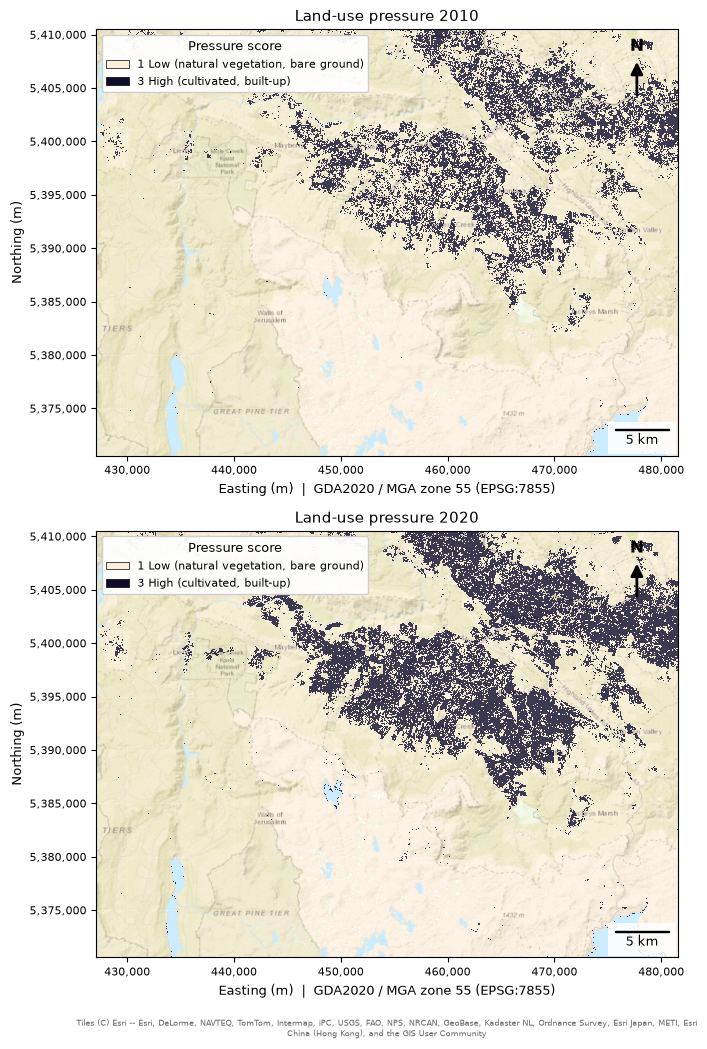

In [3]:
PRESSURE_LABELS = ["None (water)", "1 Low (natural vegetation, bare ground)", "2 (not used)", "3 High (cultivated, built-up)"]
# "Low" (natural vegetation) covers most of the map, so it is drawn as a faint tint and the basemap shows through
PRESSURE_COLOURS = np.array([[0, 0, 0, 0], plt.cm.magma_r(0.10), plt.cm.magma_r(0.60), plt.cm.magma_r(0.92)])
PRESSURE_COLOURS[1, 3] = 0.3
bounds = data_bounds(valid, profile["transform"])
fig, axes = plt.subplots(2, 1, figsize=(10, 10.5))
for ax, year in zip(axes, [2010, 2020]):
    add_basemap(ax, bounds, margin=0, zoom=11)
    plot_scores(ax, pressure_by_year[year], profile["transform"], 4, colours=PRESSURE_COLOURS)
    scores_legend(ax, PRESSURE_LABELS, title="Pressure score", colours=PRESSURE_COLOURS, skip=(0, 2))
    ax.set_title(f"Land-use pressure {year}", fontsize=11)
    finish_map(ax)
add_attribution(axes[-1])
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## An early look at the temporal trend

High-pressure (cultivated + artificial) area increased from 180,275 to 283,006 cells between 2010 and 2020 at Mole Creek, roughly a 57% increase within the buffered study area. Stage 9 extends this to the annual series (1988-2024), which shows 2010-2020 is one phase of a longer cycle.

## Stage 5 outputs

- `landuse_pressure_mc_2010_EPSG7855.tif`
- `landuse_pressure_mc_2020_EPSG7855.tif`

Both aligned to the same grid as Stages 2-4 (the Mole Creek DEM
template), so they're ready to combine directly.

**Next (Stage 6):** combine Stage 4 (intrinsic vulnerability) × Stage 5
(land-use pressure, 2020 as the primary year) into the final relative
vulnerability/risk map for Mole Creek — the prototype's main output,
before scaling statewide.